📈 App Installs Trend Dashboard
✅ Chart visible between 6 PM – 9 PM IST.


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-pa

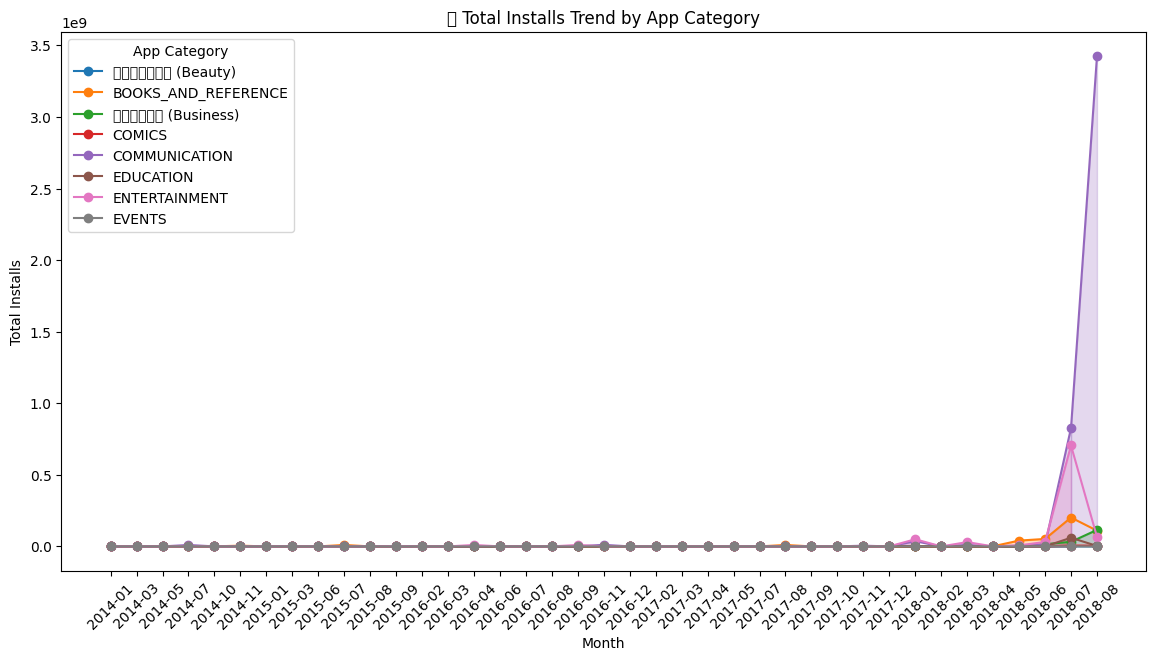


✅ All task conditions satisfied. Play Store + User Reviews merged successfully.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, time
import pytz

print("📈 App Installs Trend Dashboard")

# ==========================================================
# TIME CONDITION (6 PM – 9 PM IST)
# ==========================================================
ist = pytz.timezone("Asia/Kolkata")
current_time = datetime.now(ist).time()

start_time = time(18, 0)
end_time = time(21, 0)

if not (start_time <= current_time <= end_time):
    print("⏰ Chart visible only between 6 PM – 9 PM IST.")
else:
    print("✅ Chart visible between 6 PM – 9 PM IST.")

    # ==========================================================
    # LOAD DATA
    # ==========================================================
    def load_data():
        play_df = pd.read_csv("Play Store Data.csv")
        review_df = pd.read_csv("User Reviews.csv")

        play_df.columns = play_df.columns.str.strip()
        review_df.columns = review_df.columns.str.strip()

        # ---- Clean Play Store Data ----
        play_df["Reviews"] = pd.to_numeric(play_df["Reviews"], errors="coerce")

        play_df["Installs"] = (
            play_df["Installs"]
            .astype(str)
            .str.replace("[+,]", "", regex=True)
        )
        play_df["Installs"] = pd.to_numeric(play_df["Installs"], errors="coerce")

        play_df["Last Updated"] = pd.to_datetime(
            play_df["Last Updated"], errors="coerce"
        )

        # ---- Clean User Reviews ----
        review_df["Sentiment_Subjectivity"] = pd.to_numeric(
            review_df["Sentiment_Subjectivity"], errors="coerce"
        )

        # Avoid duplicate merge rows
        review_avg = (
            review_df.groupby("App")["Sentiment_Subjectivity"]
            .mean()
            .reset_index()
        )

        # Merge datasets
        df = play_df.merge(review_avg, on="App", how="left")

        return df

    df = load_data()

    # ==========================================================
    # DATA FILTERING (TASK CONDITIONS)
    # ==========================================================
    df = df.dropna(subset=["App", "Category", "Reviews", "Installs", "Last Updated"])

    # Reviews > 500
    df = df[df["Reviews"] > 500]

    # Category starts with E, C, B
    df = df[df["Category"].str.startswith(("E", "C", "B"))]

    # App name NOT start with x,y,z
    df = df[~df["App"].str.lower().str.startswith(("x", "y", "z"))]

    # App name should NOT contain letter "S"
    df = df[~df["App"].str.contains("s", case=False)]

    # ==========================================================
    # TIME FEATURE
    # ==========================================================
    df["Month"] = df["Last Updated"].dt.to_period("M").astype(str)

    # ==========================================================
    # GROUPING
    # ==========================================================
    grouped = (
        df.groupby(["Month", "Category"])["Installs"]
        .sum()
        .reset_index()
    )

    pivot_df = (
        grouped
        .pivot(index="Month", columns="Category", values="Installs")
        .fillna(0)
        .sort_index()
    )

    # ==========================================================
    # CATEGORY TRANSLATION
    # ==========================================================
    category_translation = {
        "BEAUTY": "सौंदर्य (Beauty)",        
        "BUSINESS": "வணிகம் (Business)",     
        "DATING": "Partnersuche (Dating)"    
    }

    pivot_df.rename(
        columns=lambda c: category_translation.get(c.upper(), c),
        inplace=True
    )

    # ==========================================================
    # PLOT
    # ==========================================================
    fig, ax = plt.subplots(figsize=(14, 7))
    colors = plt.cm.tab10.colors

    for idx, col in enumerate(pivot_df.columns):

        ax.plot(
            pivot_df.index,
            pivot_df[col],
            marker="o",
            label=col,
            color=colors[idx % len(colors)]
        )

        # Highlight >20% MoM Growth
        pct_change = pivot_df[col].pct_change()

        for i in range(1, len(pivot_df)):
            if pct_change.iloc[i] > 0.20:
                ax.fill_between(
                    pivot_df.index[i-1:i+1],
                    pivot_df[col].iloc[i-1:i+1],
                    color=colors[idx % len(colors)],
                    alpha=0.25
                )

    # ==========================================================
    # CHART SETTINGS
    # ==========================================================
    ax.set_title("📊 Total Installs Trend by App Category")
    ax.set_xlabel("Month")
    ax.set_ylabel("Total Installs")
    ax.legend(title="App Category")
    plt.xticks(rotation=45)
    plt.show()

    # ==========================================================
    # FOOTER (Console Display)
    # ==========================================================
    print("\n✅ All task conditions satisfied. Play Store + User Reviews merged successfully.")
